# 03 Model Inspection

This notebook is being built as a step-by-step model inspection guide.

Section 0 starts with a tiny PyTorch refresher. The later sections then use the same ideas to inspect `AutoencoderExcitedMACE`: modules, parameters, forward passes, and loss objects.

## 0. PyTorch Preliminaries

Before inspecting X-MACE, it helps to remember the basic PyTorch pattern: subclass `nn.Module`, define trainable layers in `__init__`, define the computation in `forward`, then call the model like a normal function.

In [2]:
import os
import numpy as np
import torch
from torch import nn
from e3nn import o3

import mace
from mace import modules

DEVICE = torch.device("cpu")
torch.set_default_dtype(torch.float64)

print("DEVICE:", DEVICE)

DEVICE: cpu


### 0.1 Lego Blocks: Individual Layers

A neural network layer is a subclass of `nn.Module`. Models are separated to tiny lego blocks, usually separated by stages because they have different functions and look different. In this example, we only use two linear layers so its abit pointless but for X-MACE this idea becomes important

In [3]:
class TinyLayer1(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        # This is a trainable layer: weight and bias are created here.
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.SiLU()

    def forward(self, x):
        # This layer maps input features into hidden features.
        x = self.linear(x)
        x = self.activation(x)
        return x


class TinyLayer2(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()

        # This is another trainable layer.
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # This layer maps hidden features into output features.
        x = self.linear(x)
        return x

### 0.2 Lego Blocks: Compose A Model

A full model is also an `nn.Module`. It is defined by joining other smaller layer blocks together. 
This is the same pattern used by X-MACE: the full model owns embedding blocks, interaction blocks, product blocks, readouts, encoder, and decoder.
The forward layer determines how the information flows between blocks

In [4]:
class TinyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        # These submodules are now registered inside the full model.
        self.layer_1 = TinyLayer1(input_dim, hidden_dim)
        self.layer_2 = TinyLayer2(hidden_dim, output_dim)

    def forward(self, x):
        # The forward pass defines the order of the Lego blocks.
        x = self.layer_1(x)
        x = self.layer_2(x)
        return x

"""
Importantly, the output of layer 1 and input of layer 2 must match here exactly 
In this minimal model, a 3 dimension vector maps to a 5 dimension vector in layer 1. 
This 5D vector then gets passed into layer 2. This 5D vector then gets mapped to a 2D output

This means that the model would expect an input that has 3 features, and will output
2 numbers. 
"""

tiny_model = TinyModel(input_dim=3, hidden_dim=5, output_dim=2).to(DEVICE)

print(tiny_model)
print("\nNamed parameters:")
for name, parameter in tiny_model.named_parameters():
    print(f"{name:24s} shape={tuple(parameter.shape)} trainable={parameter.requires_grad}")

TinyModel(
  (layer_1): TinyLayer1(
    (linear): Linear(in_features=3, out_features=5, bias=True)
    (activation): SiLU()
  )
  (layer_2): TinyLayer2(
    (linear): Linear(in_features=5, out_features=2, bias=True)
  )
)

Named parameters:
layer_1.linear.weight    shape=(5, 3) trainable=True
layer_1.linear.bias      shape=(5,) trainable=True
layer_2.linear.weight    shape=(2, 5) trainable=True
layer_2.linear.bias      shape=(2,) trainable=True


### 0.3 Forward Pass And One Training Step

A forward pass produces predictions. A loss compares predictions to targets. `loss.backward()` computes gradients, and `optimizer.step()` updates trainable parameters.

In [5]:
# One tiny batch: 4 samples, each with 3 input features.
x = torch.randn(4, 3, device=DEVICE)
y = torch.randn(4, 2, device=DEVICE)

optimizer = torch.optim.Adam(tiny_model.parameters(), lr=1.0e-3)
loss_fn = nn.MSELoss()

# 1. Clear old gradients.
optimizer.zero_grad(set_to_none=True)

# 2. Forward pass: this calls tiny_model.forward(x).
prediction = tiny_model(x)

# 3. Compute scalar loss.
loss = loss_fn(prediction, y)

# 4. Backward pass: fill parameter.grad for every trainable parameter.
loss.backward()

# 5. Optimizer step: update weights using the gradients.
optimizer.step()

print("x shape:", tuple(x.shape))
print("prediction shape:", tuple(prediction.shape))
print("target shape:", tuple(y.shape))
print("loss:", float(loss.detach().cpu()))

print("\nGradient shapes after backward:")
for name, parameter in tiny_model.named_parameters():
    print(f"{name:20s} grad_shape={tuple(parameter.grad.shape)}")

x shape: (4, 3)
prediction shape: (4, 2)
target shape: (4, 2)
loss: 0.43699620896378744

Gradient shapes after backward:
layer_1.linear.weight grad_shape=(5, 3)
layer_1.linear.bias  grad_shape=(5,)
layer_2.linear.weight grad_shape=(2, 5)
layer_2.linear.bias  grad_shape=(2,)


### 0.4 `o3` Functionalities

Molecular model predictions need to respect 3D symmetry. For example, if the same molecule is rotated in space, its energy should stay the same. More generally, scalar outputs like energies should be **rotation invariant**, while vector-like internal features should rotate in a controlled way.

`e3nn.o3` is a PyTorch-based library module that helps build neural-network layers with this symmetry built in. It provides layers that know how scalar, vector, and higher-order geometric features should transform under 3D rotations and reflections.

The most common user-facing API is:

```python
o3.Irreps(...)
```

`Irreps` means irreducible representations. In practical coding terms, it labels what kind of feature channels a tensor contains. You can think of it as a mode selector for feature types.

Examples:

```text
3x0e = 3 scalar channels
5x0e = 5 scalar channels
4x1o = 4 vector-like channels
```

An `o3.Linear` layer is then defined using two `Irreps` objects:

```python
o3.Linear(irreps_in, irreps_out)
```

This tells the layer what kind of input features it receives and what kind of output features it should produce. Unlike a plain `torch.nn.Linear`, it only mixes features in ways that respect their symmetry type.

Other important `o3` tools used in X-MACE include:

- `o3.SphericalHarmonics`: builds angular edge features from 3D directions
- `o3.TensorProduct`: combines node features with edge/angular features during message passing
- `o3.FullyConnectedTensorProduct`: a flexible tensor product used in interaction/skip paths


In [6]:
# Define the input feature type.
# 3x0e means three scalar channels.
irreps_in = o3.Irreps("3x0e")

# Define the output feature type.
# 5x0e means five scalar channels.
irreps_out = o3.Irreps("5x0e")

# Define an e3nn symmetry-aware linear layer.
# It maps features with type irreps_in -> features with type irreps_out.
linear_layer = o3.Linear(irreps_in, irreps_out)

# A tiny batch of generic scalar features.
# Shape: [n_samples, input_dim] = [4, 3]
x = torch.randn(4, irreps_in.dim, dtype=torch.get_default_dtype())

# Call the layer.
# Shape: [4, 3] -> [4, 5]
y = linear_layer(x)

# Minimal notebook display: layer object and input/output shapes.
linear_layer, x.shape, y.shape


/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


(Linear(3x0e -> 5x0e | 15 weights), torch.Size([4, 3]), torch.Size([4, 5]))

## 1. X-MACE Overview

`AutoencoderExcitedMACE` is also an `nn.Module`. It is comprised of smaller layer blocks (also nn.Module objects). However, not every layer has trainable parameters. Some layers are just math functions that map an input to an output. All these are defined in the forward layer. 

The main AutoencoderExcitedMAce class is defined in:

```text
mace/modules/models.py
```
This subsequent tutorial seeks to explore each individual layer of the model and explicitly learn about the dimensions and features of it.

This is focused on the energy-only autoencoder path. Optional NAC, SOC are not discussed 

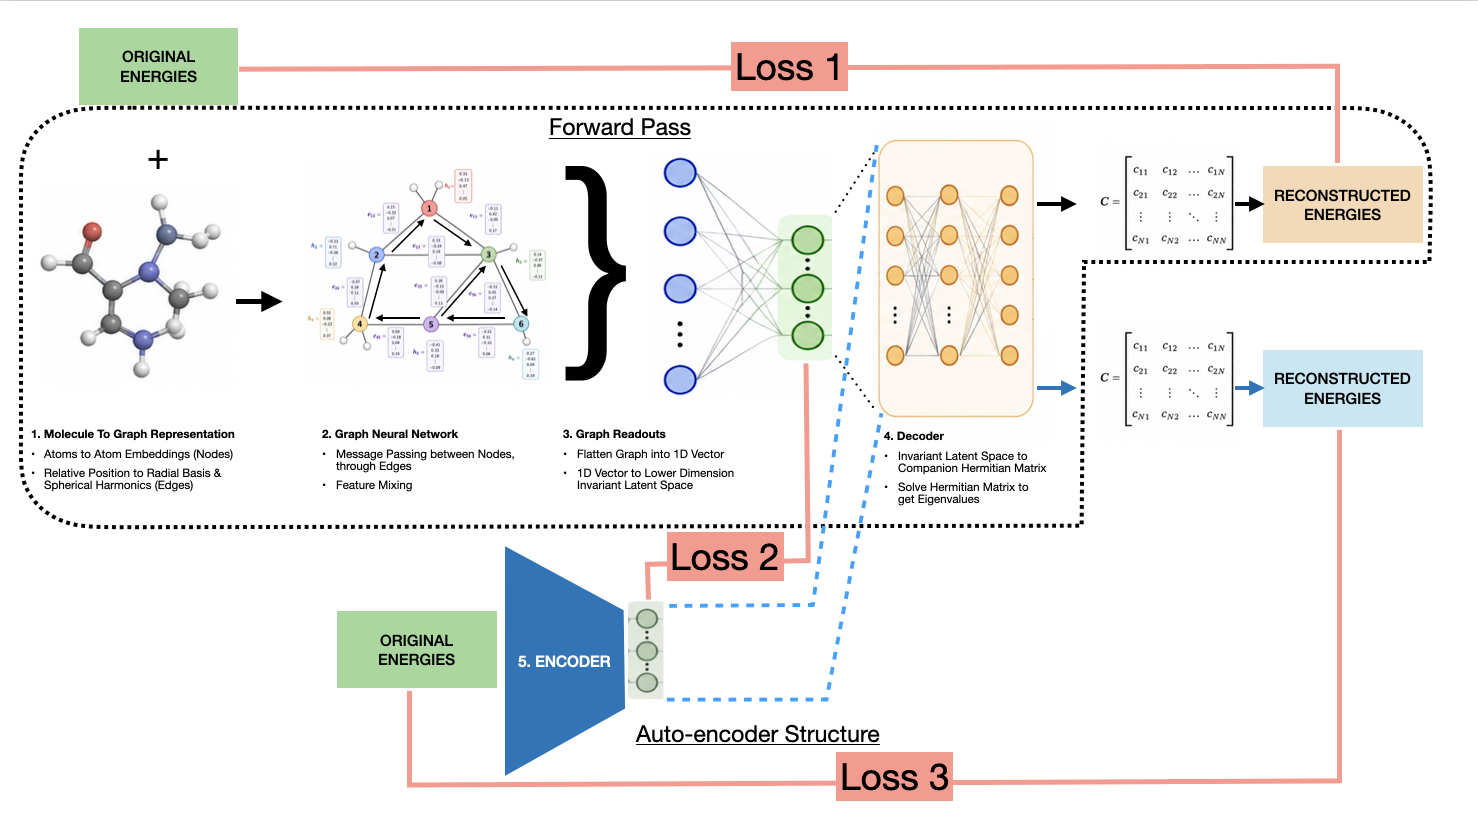

### Main blocks of X-MACE

The key stages of the X-MACE forward pass are as follows
1. Molecule to Graph Representation 
- Atoms are converted to embedding vectors via learned parameters
- Distance between atoms are converted to radial basis and spherical harmonics via two math mapping blocks. These are NOT trained layers, but pre defined function layers. These act as the edge vectors 

2. Graph Neural Network
- Each atom (node) passes messages to surrounding atoms a few times across the edges that connect them 
- Every message passing step allows atoms to learn about each other 

3. Graph Readouts 
- The final "learned" node vectors are first flattened into a high dimensional vector
- This gets mapped to an invariant low dimensional latent space 

4. Decoder 
- Decoder takes in the latent space vector, and maps it into a few matrix elements
- This will be the coefficients of the hermitian companion matrix. Diagonalising this matrix will give the n excited states 

Additionally, X-MACE uses an encoder to help to guide the training of this model. This is built on the assumption that there is a low dimensional latent space that can capture the energies and excited states well. 

The encoder is part of the model object, but it is not called inside `AutoencoderExcitedMACE.forward`. During training, the training loop separately sends the reference energies through the encoder, then compares that encoded latent target to the GNN-produced latent vector.
This is used to guide the loss, such that the latent space is something that can be reached by the GNN and something that can be encoded directly from the energies. 

The GNN, invariant readout, encoder, and decoder weights are optimized together during each training step.

### Datastructure

X-MACE uses PyTorch Geometric-style graph batches. A single geometry is converted into an `AtomicData` object. A dataloader then combines several `AtomicData` objects into one batched object. In the training loop, that batch is converted into a dictionary before it enters the model:

```python
batch = batch.to(device)
data = batch.to_dict()
output = model(data, ...)
```

So inside `AutoencoderExcitedMACE.forward`, `data` is a dictionary of tensors. The important idea is that the dataloader does not keep molecules as a Python list. Instead, it concatenates them into one larger disconnected graph. The model keeps track of which atom belongs to which molecule using `batch` and `ptr`.

Notation used below:

| Symbol | Meaning |
|---|---|
| `G` | number of geometries / molecules in the batch |
| `N` | total number of atoms IN THE BATCH, summed over all `G` geometries |
| `E` | total number of directed edges IN THE BATCH after neighbor-list construction |
| `Z` | number of allowed element types, for example C/H/O/etc. |
| `S` | number of electronic states / energy channels, for example `4` in the small X-MACE tutorial |

Main dataloader keys:

| Key | Typical shape after batching | Meaning | Intuition |
|---|---:|---|---|
| `node_attrs` | `[N, Z]` | one-hot atom identity; one row per atom | if allowed elements are `[C, H]`, carbon is `[1, 0]` and hydrogen is `[0, 1]` |
| `positions` | `[N, 3]` | xyz coordinates for every atom | all atom coordinates from all molecules are stacked together |
| `edge_index` | `[2, E]` | directed graph connectivity; row 0 sender, row 1 receiver | edges only connect atoms within the same molecule, so the batch is one disconnected mega-graph |
| `batch` | `[N]` | graph index for each atom | example: `[0, 0, 0, 1, 1, 1, 1]` means the first 3 atoms belong to molecule 0 and the next 4 atoms belong to molecule 1 |
| `ptr` | `[G + 1]` | cumulative atom counts per geometry | example: `[0, 3, 7]` means molecule 0 uses atoms `0:3`, molecule 1 uses atoms `3:7` |
| `energy` | `[G, S]` or `[G]` | target energy per geometry | molecule-level label; one row per molecule, not one row per atom |
| `forces` | `[N, S, 3]` or `[N, 3]` | target force vectors per atom | atom-level label, so it follows the stacked atom dimension `N` |
| `weight` | `[G]` | per-configuration weight | scales the contribution of each molecule/configuration in the loss. Now its all 1s but likely useful for TL with old and new data?? |
| `energy_weight` | `[G]` | per-configuration energy weight | scales the energy part of the loss |
| `forces_weight` | `[G]` | per-configuration force weight | scales the force part of the loss |

** There are other attributes like shifts / unit shifts / cell for periodic lattices or crystals, or NAC and SOC that arent too relevant for this project

The key separation mechanism is `batch`. For example, after message passing, the model may have atom-level values with shape `[N, ...]`. To recover molecule-level values, it sums atoms with the same `batch` index:

```text
atom values: [atom0, atom1, atom2, atom3, atom4, atom5, atom6]
batch:       [0,     0,     0,     1,     1,     1,     1]

molecule 0 = atom0 + atom1 + atom2
molecule 1 = atom3 + atom4 + atom5 + atom6
```

Example: if `batch_size = 2`, each molecule has 3 atoms, and the element table is `[C, H]`, then `G = 2`, `N = 6`, `Z = 2`, and `data["node_attrs"].shape == [6, 2]`. The model does not see two separate `[3, 2]` tensors; it sees one concatenated graph batch plus `batch`/`ptr` telling it which atoms belong to which molecule.


## 2. Molecule to Graph Conversion

From the data dict, that information needs to be converted into a graph that the model can read

### 2.1 Atomic Embeddings

First there is the atomic embedding step, which forms the node features of the graph.

```python
node_feats = self.node_embedding(data["node_attrs"])
```

Here, `data["node_attrs"]` is the input tensor. 
For a tiny molecule with atoms `C, H, H` and allowed elements `[C, H]`:

```text
C -> [1, 0]
H -> [0, 1]
H -> [0, 1]
```

The node_embedding is defined to be something like 
```python
node_embedding = LinearNodeEmbeddingBlock(
    irreps_in=o3.Irreps("2x0e"),
    irreps_out=o3.Irreps("4x0e"),
).to(DEVICE)
```
This means we start with 2 scalar inputs (C and H) and maps it into 4 scalar outputs (the learned 4D representation).

Dimensions:
```text
node_attrs: [n_atoms, n_elements] = [3, 2]
node_feats: [n_atoms, embedding_dim] = [3, 4]
```


### 2.2 Radial Basis

For the edges of the graphs, there are two pieces of information that it learns from. 
The first is the radial basis, which creates the **edge distance features** of the graph. This basically represents how far two atoms are apart. Only consider the scalar magnitude value. 

The model first uses `positions`(xyz coords) and `edge_index` (connection labels) to calculate the vector and distance for every directed edge:

```python
vectors, lengths = get_edge_vectors_and_lengths(
    positions=data["positions"],
    edge_index=data["edge_index"],
    shifts=data["shifts"],
)
```
Vectors is used later on for spherical harmonics. 
Lengths is just a scalar value. This value is expanded into radial basis features. Basically instead of just writing a distance equal to like 1.1A, it is converted into a vector like with coefficients like [f1(1.1), f2(1.1), f3(1.1), f4(1.1)] 

Intuitively f1 to f4 would represent something like lower to higher numbers, so a smaller number might be encoded as something like [0.9, 0.3, 0.2, 0.1], while a larger number say 2.0A might be [0.1, 0.2, 0.8, 0.4]. 


```python
edge_feats = self.radial_embedding(
    lengths,
    data["node_attrs"],
    data["edge_index"],
    self.atomic_numbers,
)
```

Optional Arguments:
```text
radial_type = [bessel, gaussian, chebyshev] --> Different math maps can be used
num_bessel = int --> Controls length of vector
```

Dimensions:

```text
positions:  [n_atoms, 3]
edge_index: [2, n_edges]

vectors:    [n_edges, 3]
lengths:    [n_edges, 1]
edge_feats: [n_edges, num_bessel]
```

### 2.3 Spherical Harmonics

Spherical harmonics create the **edge direction features** of the graph. This is saved as edge_attrs. 

```python
edge_attrs = self.spherical_harmonics(vectors)
```

Basicaly the xyz coordinates are mapped to a vector via spherical harmonics. 

The output dimension is controlled by `max_ell`. For `max_ell = 2`, X-MACE uses:

```text
1x0e + 1x1o + 1x2e
```

The dimensions are:

```text
0e: 1 channel  -> Scalar
1o: 3 channels -> Vector 
2e: 5 channels -> Rank 2 Tensor

total = 1 + 3 + 5 = 9
```

Spherical harmonics are used here because they can be cleanly separated into scalar-like, vector-like, tensor-like terms. Later on in the message passing layer, it becomes apparent why it matters. 


### 2.4 Net Summary Of The Graph

At this point, the molecule has been converted into node tensors and edge tensors. It is useful to separate the tensors into the **inputs from the data object** and the **features created by the model**.

Input tensors:

| Tensor | What it stores | Where it comes from | Tiny example shape |
|---|---|---|---:|
| `node_attrs` | atom identity as one-hot vectors | atom symbols + element table | `[3, 2]` |
| `positions` | xyz coordinates for each atom | molecular geometry | `[3, 3]` |
| `edge_index` | directed graph connectivity | neighbor list | `[2, 6]` |


Output tensors created from those inputs:

| Tensor | What it stores | Built from | Tiny example shape |
|---|---|---|---:|
| `node_feats` | learned atom embedding vectors | `node_embedding(node_attrs)` | `[3, 4]` |
| `edge_feats` | radial distance basis features | `radial_embedding(lengths, ...)` | `[6, 4]` |
| `edge_attrs` | angular direction features | `spherical_harmonics(vectors)` | `[6, 9]` |

The GNN then uses:

```text
node_feats + edge_index + edge_feats + edge_attrs
```

to let atoms exchange information through message passing.


## 3. GNN: Message Passing And Product

Once the molecule has been converted into node and edge tensors, the GNN updates each atom's learned feature vector by passing messages along the directed edges.

In the model forward pass, each GNN stage is called here:

```python
node_feats, sc = interaction(
    node_attrs=data["node_attrs"],
    node_feats=node_feats,
    edge_attrs=edge_attrs,
    edge_feats=edge_feats,
    edge_index=data["edge_index"],
)
```

### 3.1 One Message Passing Step

At the start, the node features are scalar-only:

```text
node_feats: 8x0e
```

This means each atom has 8 scalar channels. These are learned atom features, but they do not yet contain vector-like directional channels.

The edge information is fixed for the geometry:

```text
edge_feats: radial distance features, e.g. 8x0e
edge_attrs: angular direction features, e.g. 1x0e + 1x1o + 1x2e
```

So each directed edge carries two kinds of information:

```text
edge_feats = how far the neighbor is
edge_attrs = which direction the neighbor is
```

For one directed edge `sender -> receiver`, the interaction block uses:

```text
sender node feature + edge distance feature + edge direction feature
```

to form a message that updates the receiver atom.

The key implementation inside the interaction block is roughly:

```python
tp_weights = self.conv_tp_weights(edge_feats)
mji = self.conv_tp(node_feats[sender], edge_attrs, tp_weights)
message = scatter_sum(src=mji, index=receiver, dim=0, dim_size=num_nodes)
```

Important: this is not just a normal dense layer on a flattened tensor. The important `o3` operation is the tensor product:

```python
self.conv_tp(...)
```

This tensor product uses the irreps metadata to only allow symmetry-valid mixing. Similar to how two vectors dot product is rotationally invariant, this tensor product produces scalars sometimes.

So a good mental model is that each node will have a mix of scalar-like, vector-like, tensor-like terms (after 1 round of message passing). The output of a two vector like terms for eg can be a scalar. That already gives you a form of data that is rotationally invariant, that also encodes relative direction. 



### 3.2 Bidirectional Graph

The graph uses directed edges, meaning the edges point from one atom to another. This information is encoded in `edge_index`.

Message passing is bidirectional, meaning for one atom pair,

```text
0 -> 1 uses node_feats[0] to update atom 1
1 -> 0 uses node_feats[1] to update atom 0
```
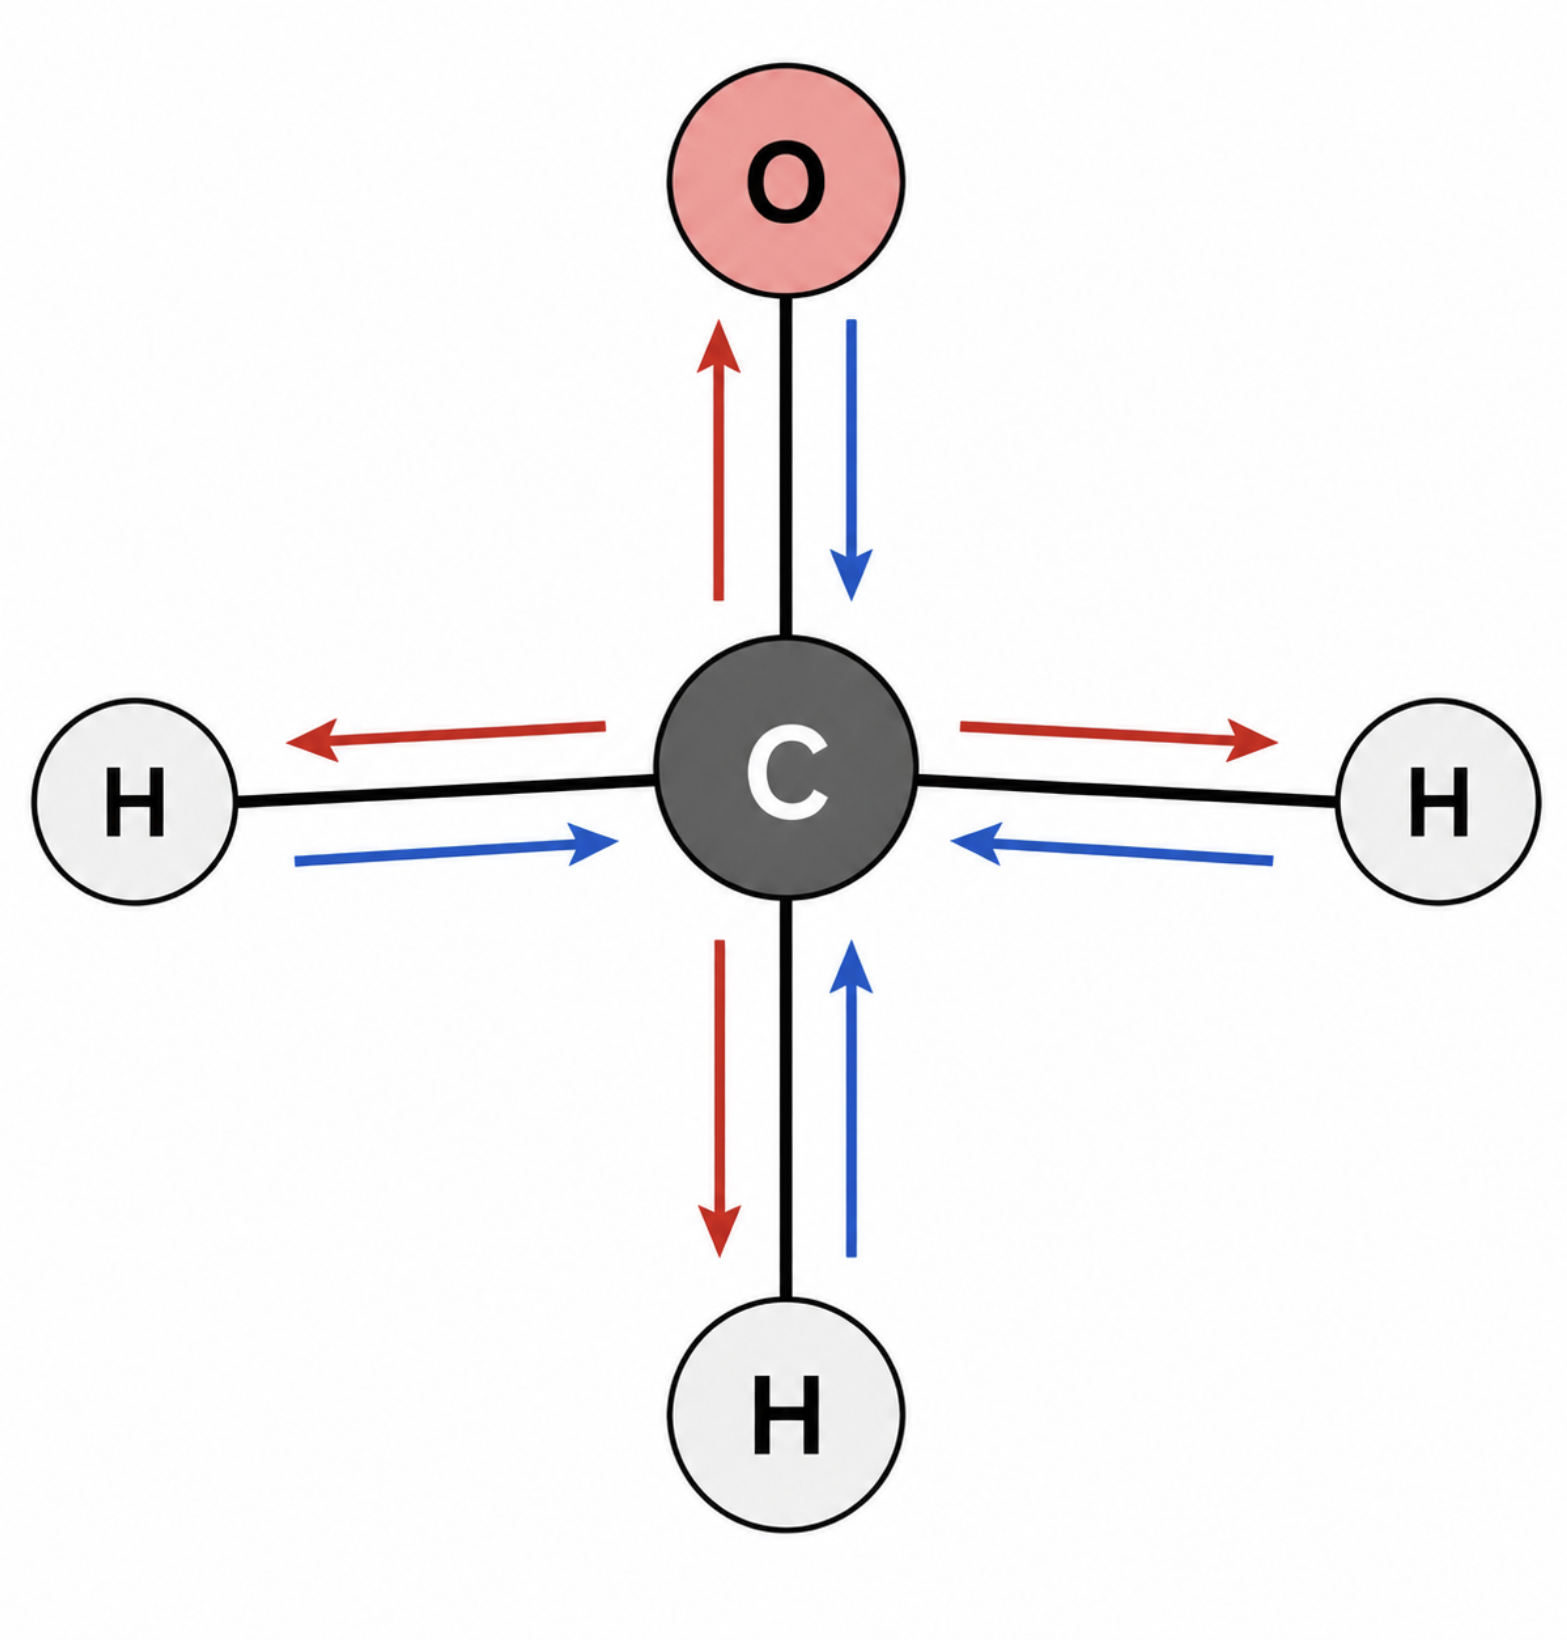

### 3.3 Product Block

After the iteraction block when atoms learn about each other, it goes through one more product block 

``` python
node_feats = product(
    node_feats=node_feats,
    sc=sc,
    node_attrs=data["node_attrs"],
)
```
Roughly speaking, each atom has a node that can have features like 
``` text
Scalar feature s₁
Scalar feature s₂
Vector feature v₁
Vector feature v₂
```

This product block allows it to form things like 
``` text
v₁ × v₂
s₁ × v₁
s₂ × v₂
...
```

The point is that this is MIXING done WITHIN each atom node. So the node features still remain as 1 atom 1 node.

This mixing might seem pointless, but intuitively its probably because each atom eg maybe a C1, receives messages from C2 and H1. This mixing allows for the messages to then learn about each other. Before they were just independently passing messages to C1. 
```

## 4. Invariant Readout

After the node features are "fully learned", they are then converted into a lower dimensional latent space.

```python
invariant_readout = LinearReadoutBlock(
    irreps_in=hidden_irreps,
    n_energies=latent_dim,
    compute_nacs=False,
    nac_indices=0,
).to(DEVICE)
```
This model essentially takes only the scalar irreps from the graph nodes. These values are CONSTANT no matter the rotation. 

The model sums those atom-level contributions over atoms in the same molecule:

```python
invariant_vals = scatter_sum(...)
```

This is then "compressed" by a regular FFNN into a low dimensional latent space. This is called a invariant latent space because only the scalar terms have been selected. 

The key theory here for X-MACE on why we need to map to a low dimensional latent space is because they hypothesise that there is a low dimensional manifold that can determine the entire spectrum of excited states. 16D was just found to work well 


## 5. Decoder

The autoencoder decoder receives the graph-level latent vector:

```python
decoded_vals = self.perm_decoder(invariant_vals)
```

This decoder structure is architecturally the simplest to understand because it is nothing more than a FFNN, but it also contains the most weights and parameters. 

By default structually it has 5 linear layers,
Latent dimension is default 16, hidden dim is default 128
```text
Linear(latent_dim=16,  hidden_dim=128)
ELU()
Linear(hidden_dim=128, hidden_dim=128)
ELU()
Linear(hidden_dim=128, hidden_dim=128)
ELU()
Linear(hidden_dim=128, hidden_dim=128)
ELU()
Linear(hidden_dim=128, matrix_vals)
```

This does not predict all matrix elments. Instead, it only predicts the diagonal and off-diagonal values, reconstructs a symmetric tridiagonal matrix (hermitian). As such matrix vals is equal to 2*N-1, whereby N is number of excited states 

Then, it diagonalises that matrix to find the eigenvalues which give the excited state energies. 
```


## 6. Encoder

The encoder is part of the `AutoencoderExcitedMACE` model object, but it is not called inside `AutoencoderExcitedMACE.forward`.

During training, the training loop separately encodes the reference energies:

```python
encoded_energy = model.perm_encoder(centred_energy)
```
Such that centered energy is the original energy minus the baseline E0 that we fed the model. So we only train the encoder on the "corrections"

### 6.1 Rough Structure
This encoder by default uses 4 linear layers 
```text
Linear(input_dim=1, hidden_dim=16)
ELU()
Linear(hidden_dim=16, hidden_dim=16)
ELU()
Linear(hidden_dim=16, hidden_dim=16)
ELU()
Linear(hidden_dim=16, hidden_dim=16)
ELU()
```
This maps to a "encoded latent space"

Rough flow:

```text
reference energy states -> encoded latent target -> same decoder -> predicted "decoded energy"
```

### 6.2 Purpose 
The point of this structure is so that the autoencoder guides the model to find a latent space that nicely represents the energy spectrum. 

The encoder gives the loss a latent target to compare against the GNN-produced `invariant_vals`. 

This autoencoder is trained together with the other parts so that the model can hopefully find a latent space that can represent the energies well, but also can be found from the graph easily. 

## 7. Loss Function

For the autoencoder model, the energy part of the loss uses three comparisons:

```python
ref["energy"]              vs pred["energy"]
ref["energy"]              vs pred["decoded_energy"]
pred["encoded_energy"]     vs pred["invariant_vals"]
```

OR more simply:
```text
1) (GNN + Decoder) energy prediction loss +
2) (Encoder + Decoder) reconstruction loss + 
3) Learned Latent space (from GNN) vs Encoded Latent space (from        energies) ALIGNMENT loss
```


## 8. Layer Summary Tables

These tables summarize the main layers and tensor transformations used in the simplified walkthrough above. The exact dimensions depend on the model hyperparameters, but the examples here use the toy molecule from this notebook.

### Molecule To Graph

| Name | Function | Irreps / Feature Type | Input Dimension | Output Dimension |
|---|---|---|---|---|
| `node_attrs` | Atom identity tensor, stored as `data["node_attrs"]` | `2x0e`, scalar atom-type channels | `C,H,H` atom symbols | `[n_atoms, n_elements] = [3, 2]` |
| `node_embedding` | `LinearNodeEmbeddingBlock`; maps atom identity into learned atom features | `2x0e -> 4x0e` | `node_attrs: [3, 2]` | `node_feats: [3, 4]` |
| `edge geometry` | `get_edge_vectors_and_lengths`; builds edge vectors and distances | ordinary coordinate tensors | `positions: [3, 3]`, `edge_index: [2, 6]` | `vectors: [6, 3]`, `lengths: [6, 1]` |
| `radial_embedding` | `RadialEmbeddingBlock`; expands edge distances into radial basis features | `4x0e`, scalar edge-distance channels | `lengths: [6, 1]` | `edge_feats: [6, 4]` |
| `spherical_harmonics` | `o3.SphericalHarmonics`; converts edge directions into angular features | `1x0e + 1x1o + 1x2e` | `vectors: [6, 3]` | `edge_attrs: [6, 9]` |

### GNN And Readout

| Name | Function | Irreps / Feature Type | Input Dimension | Output Dimension |
|---|---|---|---|---|
| `interaction` | `RealAgnosticInteractionBlock`; sends messages along edges | input `4x0e`; message irreps from spherical harmonics | `node_feats: [3, 4]`, `edge_feats: [6, 4]`, `edge_attrs: [6, 9]` | `message_feats: [3, interaction_dim]` |
| `product` | `EquivariantProductBasisBlock`; mixes message features into hidden node features | `interaction_irreps -> 4x0e + 4x1o` | `message_feats: [3, interaction_dim]` | `updated_node_feats: [3, 16]` |
| `invariant_readout` | `LinearReadoutBlock`; maps node features into latent contributions | `4x0e + 4x1o -> 4x0e` | `updated_node_feats: [3, 16]` | `node_invariant_output: [3, 4]` |
| `scatter_sum` | Sums atom-level latent contributions into one graph-level latent vector | scalar latent channels | `node_invariant_output: [3, 4]` | `invariant_vals: [1, 4]` |

### Autoencoder And Loss

| Name | Function | Irreps / Feature Type | Input Dimension | Output Dimension |
|---|---|---|---|---|
| `perm_decoder` | `PermutationInvariantDecoder`; decodes latent vector into energy states | ordinary PyTorch MLP, no e3nn irreps | `invariant_vals: [1, 4]` | `decoded_energy: [1, 4]` |
| `perm_encoder` | `PermutationInvariantEncoder`; encodes reference energy states into latent target space | ordinary PyTorch MLP, no e3nn irreps | `reference_energy: [1, 4, 1]` | `encoded_energy: [1, 4]` |
| `energy_loss` | `mean_squared_error_energy`; compares predicted and reference energies | scalar energy channels | `ref["energy"]`, `pred["energy"]` | scalar loss |
| `recon_loss` | `reconstruction_error_invariants`; checks decode-from-encoded-energy reconstruction | scalar energy channels | `ref["energy"]`, `pred["decoded_energy"]` | scalar loss |
| `latent_loss` | `mean_squared_error_invariants`; aligns encoder and GNN latent vectors | scalar latent channels | `pred["encoded_energy"]`, `pred["invariant_vals"]` | scalar loss |
